In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import imageio
import math

In [2]:
#Declaramos valores numéricos 
G = 6.67*10**(-11)  #N m^2/Kg^2
MT = 5.9736*10**24  #Kg
ML = 0.07349*10**24  #Kg
dTL = 3.844*10**8  #m
w = 2.6617*10**(-6) #s^-1
RT = 6.37816*10**6  #m
RL = 1.7374*10**6  #m
ve = 11194.4 #m/s


#Definimos parámetros
#Parámetros del tiempo
T =10**3
h = 30 
t = np.zeros(T)
#Masa de la nave
m = 1000

In [3]:
#Creamos las matrices de las variables que vamos a utilizar
luna = np.zeros((T,2))
nave = np.zeros((T,2))

r = np.zeros(T)
phi = np.zeros(T)
theta = np.zeros(T)
p_r = np.zeros(T)
p_phi = np.zeros(T)

In [4]:
#Condiciones iniciales
r[0] = RT 
phi[0] = 0
theta[0] = np.pi/4
p_r[0] = ve*np.cos(theta[0]-phi[0])
p_phi[0] = r[0]*ve*np.sin(theta[0]-phi[0])


#Reescalamos
r = r/dTL
p_r = p_r/(m*dTL)
p_phi = p_phi/(m*dTL**2)
#Por tanto, ahora durante el algoritmo dTL=1 y w=1

In [5]:
#Definimos las funciones que vamos a necesitar

delta = (G*MT)/dTL**3
mu = ML/MT


def r_punto(p_r):
    return p_r


def phi_punto(r, p_phi):
    return p_phi/r**2


def p_r_punto(r, phi, p_phi, t):
    r_prima = (1+r**2-2*r*np.cos(phi-2.6617*10**(-6)*t))**0.5
    return (p_phi**2/r**3) - delta*(1/r**2 + (mu/r_prima)*(r-np.cos(phi-2.6617*10**(-6)*t)))


def p_phi_punto(r, phi, t):
    r_prima = (1+r**2-2*r*np.cos(phi-2.6617*10**(-6)*t))**0.5
    return -((delta*mu*r)/r_prima**3)*np.sin(phi-2.6617*10**(-6)*t)

In [6]:
#Definimos las k como una matriz
k1 = np.zeros((4,T))
k2 = np.zeros((4,T))
k3 = np.zeros((4,T))
k4 = np.zeros((4,T))


for n in range(T-1):
    
    luna[n][0] = np.cos(t[n])
    luna[n][1] = np.sin(t[n])
    
    nave[n][0] = r[n]*np.cos(phi[n])
    nave[n][1] = r[n]*np.sin(phi[n]) 
    
    
    k1[0][n] = h*r_punto(p_r[n])
    k1[1][n] = h*phi_punto(r[n], p_phi[n])
    k1[2][n] = h*p_r_punto(r[n] , phi[n], p_phi[n], t[n])
    k1[3][n] = h*p_phi_punto(r[n] , phi[n], t[n])

    k2[0][n] = h*r_punto(p_r[n]+k1[0][n]/2)
    k2[1][n] = h*phi_punto(r[n]+k1[1][n]/2, p_phi[n]+k1[1][n]/2)
    k2[2][n] = h*p_r_punto(r[n]+k1[2][n]/2 , phi[n]+k1[2][n]/2, p_phi[n]+k1[2][n]/2, t[n]+h/2)
    k2[3][n] = h*p_phi_punto(r[n]+k1[3][n]/2 , phi[n]+k1[3][n]/2, t[n]+h/2)

    k3[0][n] = h*r_punto(p_r[n]+k2[0][n]/2)
    k3[1][n] = h*phi_punto(r[n]+k2[1][n]/2, p_phi[n]+k2[1][n]/2)
    k3[2][n] = h*p_r_punto(r[n]+k2[2][n]/2 , phi[n]+k2[2][n]/2, p_phi[n]+k2[2][n]/2, t[n]+h/2)
    k3[3][n] = h*p_phi_punto(r[n]+k2[3][n]/2 , phi[n]+k2[3][n]/2, t[n]+h/2)

    k4[0][n] = h*r_punto(p_r[n]+k3[0][n])
    k4[1][n] = h*phi_punto(r[n]+k3[1][n], p_phi[n]+k3[1][n])
    k4[2][n] = h*p_r_punto(r[n]+k3[2][n] , phi[n]+k3[2][n], p_phi[n]+k3[2][n], t[n]+h)
    k4[3][n] = h*p_phi_punto(r[n]+k3[3][n] , phi[n]+k3[3][n], t[n]+h)


    r[n+1] = r[n]+(1/6)*(k1[0][n]+2*k2[0][n]+2*k3[0][n]+k4[0][n]) 
    phi[n+1] = phi[n]+(1/6)*(k1[1][n]+2*k2[1][n]+2*k3[1][n]+k4[1][n])
    p_r[n+1] = p_r[n]+(1/6)*(k1[2][n]+2*k2[2][n]+2*k3[2][n]+k4[2][n])
    p_phi[n+1] = p_phi[n]+(1/6)*(k1[3][n]+2*k2[3][n]+2*k3[3][n]+k4[3][n])
    
    
    t[n+1] = t[n]+h

In [7]:
#Desreescalamos
r = r*dTL
luna = luna*dTL
p_r = p_r*(m*dTL)
p_phi = p_phi*(m*dTL**2)

In [8]:
print('################')
print(r)
print('################')
print(luna)
print('################')
print(p_r)
print('################')
print(p_phi)
print('################')

################
[6.37816000e+06 6.68473259e+06 8.70815080e+06 ... 2.08354782e+20
 2.08356865e+20 2.08358949e+20]
################
[[ 3.84400000e+08  0.00000000e+00]
 [ 5.92942573e+07 -3.79799356e+08]
 [-3.66107550e+08 -1.17169203e+08]
 ...
 [-3.84184395e+08 -1.28728604e+07]
 [-7.19797931e+07  3.77600674e+08]
 [ 0.00000000e+00  0.00000000e+00]]
################
[7.91563615e+03 5.22442091e+04 4.98671973e+04 ... 5.38015841e+13
 5.38015841e+13 5.38015841e+13]
################
[5.04871939e+10 5.04871941e+10 5.04925941e+10 ... 5.04902378e+10
 5.04902378e+10 5.04902378e+10]
################


In [9]:
#Comprobamos que se conserve el Hamiltoniano
H = np.zeros(T)
Hpri = np.zeros(T)

for n in range(T-1):
    H[n] = p_r[n]**2/(2*m) + p_phi[n]**2/(2*m*r[n]) - (G*m*MT)/r[n] - (G*m*ML)/(luna[n][0]**2+luna[n][1]**2)**0.5
    Hpri[n] = H[n]-w*p_phi[n]

err = 100 * abs((Hpri[0]-Hpri[T-2])/Hpri[0])

print(Hpri)
print()
print(f'Error relativo (%): {err} %')

[1.37336985e+11 1.31039236e+11 1.00619585e+11 ... 1.44730522e+24
 1.44730522e+24 0.00000000e+00]

Error relativo (%): 1053835008259214.5 %


In [10]:
#Creamos el gif

xL = luna[:,0]
yL = luna[:,1]

xN = nave[:,0]
yN = nave[:,1]

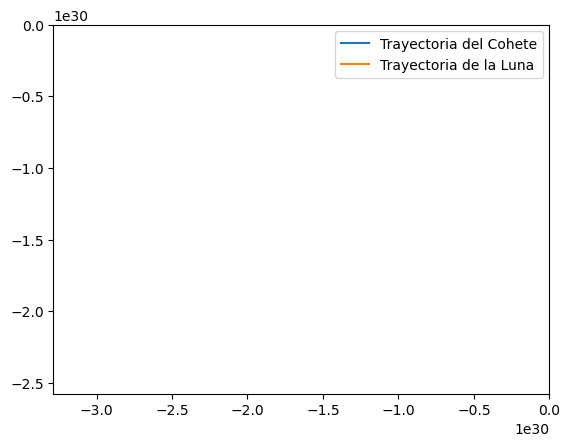

In [10]:
#Gif que no da error pero tampoco hace gif

# Configurar la figura y los ejes
fig, ax = plt.subplots()
fig.set_size_inches(6.4, 4.8)
ax.set_xlim(min(min(xN), min(xL)) - 1, max(max(xN), max(xL)) + 1)
ax.set_ylim(min(min(yN), min(yL)) - 1, max(max(yN), max(yL)) + 1)
line_cohete, = ax.plot([], [], label='Trayectoria del Cohete')
line_luna, = ax.plot([], [], label='Trayectoria de la Luna')
point_cohete, = ax.plot([], [], 'ro')  # Punto del cohete actual
point_luna, = ax.plot([], [], 'bo')  # Punto de la luna actual
ax.legend()

# Función para actualizar el gráfico
def update_plot(i):
    line_cohete.set_data(xN[:i+1], yN[:i+1])
    line_luna.set_data(xL[:i+1], yL[:i+1])
    point_cohete.set_data([xN[i]], [yN[i]])  # Cambiado para usar listas
    point_luna.set_data([xL[i]], [yL[i]])  # Cambiado para usar listas
    return [line_cohete, line_luna, point_cohete, point_luna]


In [11]:
#Gif que da error pero hace gif

# Configurar la figura y los ejes
fig, ax = plt.subplots()
ax.set_xlim(min(min(xN), min(xL)) - 1, max(max(xN), max(xL)) + 1)
ax.set_ylim(min(min(yN), min(yL)) - 1, max(max(yN), max(yL)) + 1)
line_cohete, = ax.plot([], [], label='Trayectoria del Cohete')
line_luna, = ax.plot([], [], label='Trayectoria de la Luna')
point_cohete, = ax.plot([], [], 'ro')  # Punto del cohete actual
point_luna, = ax.plot([], [], 'bo')  # Punto de la luna actual
ax.legend()

# Función para actualizar el gráfico
def update_plot(i):
    line_cohete.set_data(xN[:i+1], yN[:i+1])
    line_luna.set_data(xL[:i+1], yL[:i+1])
    point_cohete.set_data(xN[i], yN[i])
    point_luna.set_data(xL[i], yL[i])
    return [line_cohete, line_luna, point_cohete, point_luna]

# Crear el GIF
with imageio.get_writer('trayectoria.gif', mode='I', duration=0.1) as writer:
    for i in range(len(xN)):
        if i%200 == 0:
            update_plot(i)
            fig.canvas.draw()  # Actualizar la figura
            image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
            image = image.reshape(fig.canvas.get_width_height()[::-1] + (3,))
            writer.append_data(image)

plt.close(fig)  # Cerrar la figura al final

print('GIF guardado como trayectoria.gif')

C:\Users\Usuario\AppData\Local\Temp\ipykernel_11336\1188513326.py:17: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  point_cohete.set_data(xN[i], yN[i])
C:\Users\Usuario\AppData\Local\Temp\ipykernel_11336\1188513326.py:18: MatplotlibDeprecationWarning: Setting data with a non sequence type is deprecated since 3.7 and will be remove two minor releases later
  point_luna.set_data(xL[i], yL[i])
C:\Users\Usuario\AppData\Local\Temp\ipykernel_11336\1188513326.py:27: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed two minor releases later. Use buffer_rgba instead.
  image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')


GIF guardado como trayectoria.gif
